# Introduction and Dataset Overview

Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings("ignore")

Load the Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/ML/Stroke.csv')
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [ ]:
for col in ['id']:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)

In [ ]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [ ]:
X = df.drop('stroke', axis=1)

Dataset Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   object 
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   object 
 5   work_type          5110 non-null   object 
 6   Residence_type     5110 non-null   object 
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     5110 non-null   object 
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 439.3+ KB


# Exploratory Data Analysis (EDA)

In [ ]:
df.nunique()

,0
gender,3
age,104
hypertension,2
heart_disease,2
ever_married,2
work_type,5
Residence_type,2
avg_glucose_level,3979
bmi,418
smoking_status,4


In [ ]:
df.describe(include='all')

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
count,5110,5110.000000,5110.000000,5110.000000,5110,5110,5110,5110.000000,4909.000000,5110,5110.000000
unique,3,NaN,NaN,NaN,2,5,2,NaN,NaN,4,NaN
top,Female,NaN,NaN,NaN,Yes,Private,Urban,NaN,NaN,never smoked,NaN
freq,2994,NaN,NaN,NaN,3353,2925,2596,NaN,NaN,1892,NaN
mean,NaN,43.226614,0.097456,0.054012,NaN,NaN,NaN,106.147677,28.893237,NaN,0.048728
std,NaN,22.612647,0.296607,0.226063,NaN,NaN,NaN,45.283560,7.854067,NaN,0.215320
min,NaN,0.080000,0.000000,0.000000,NaN,NaN,NaN,55.120000,10.300000,NaN,0.000000
25%,NaN,25.000000,0.000000,0.000000,NaN,NaN,NaN,77.245000,23.500000,NaN,0.000000
50%,NaN,45.000000,0.000000,0.000000,NaN,NaN,NaN,91.885000,28.100000,NaN,0.000000
75%,NaN,61.000000,0.000000,0.000000,NaN,NaN,NaN,114.090000,33.100000,NaN,0.000000


Target Class Distribution

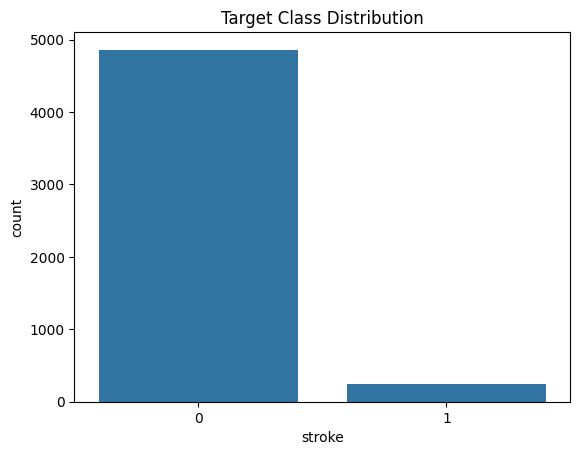

In [ ]:
sns.countplot(x='stroke', data=df)
plt.title("Target Class Distribution")
plt.show()

Gender Distribution

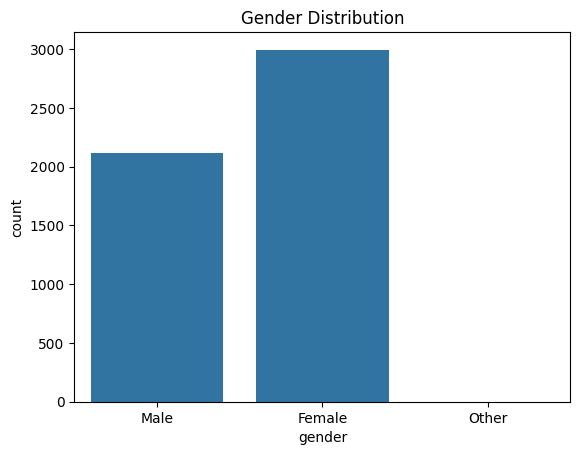

In [ ]:
sns.countplot(x='gender', data=df)
plt.title("Gender Distribution")
plt.show()

Age Distribution

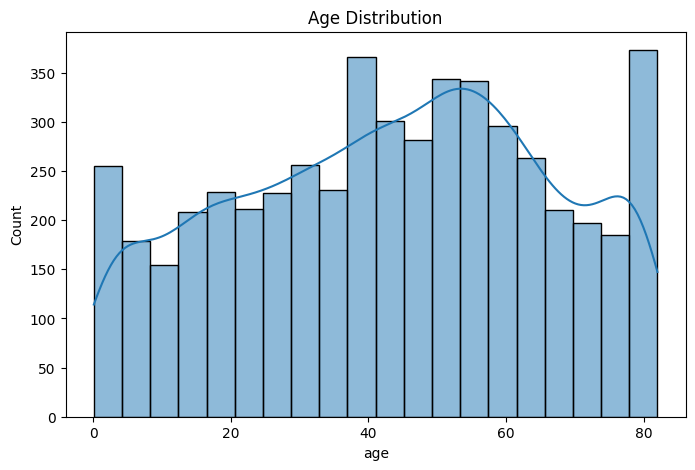

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], kde=True)
plt.title("Age Distribution")
plt.show()

Boxplot for Age vs Stroke

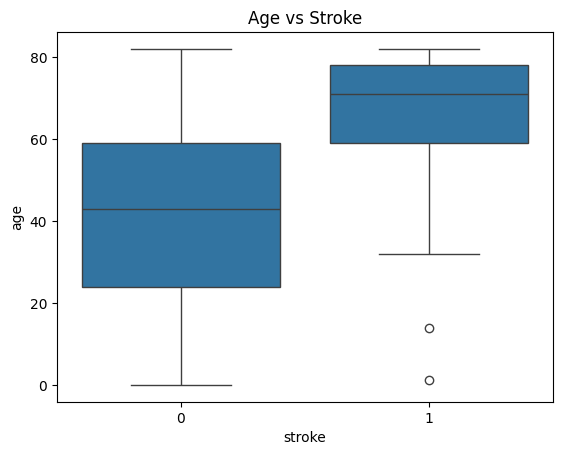

In [ ]:
sns.boxplot(x='stroke', y='age', data=df)
plt.title("Age vs Stroke")
plt.show()

Correlation Heatmap (Only Numeric Columns)

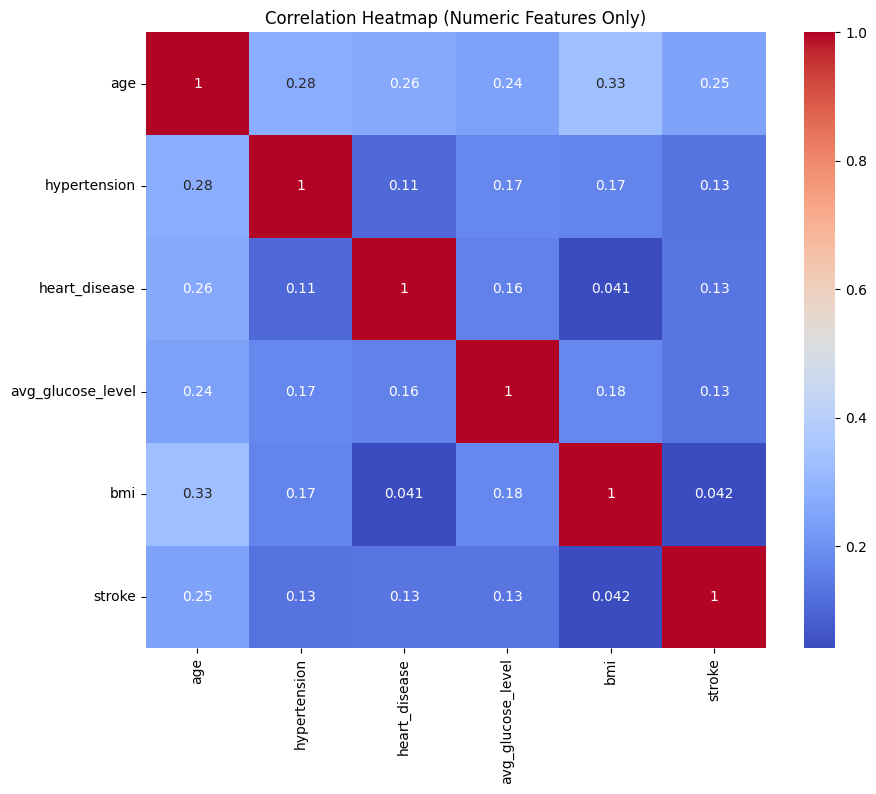

In [ ]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap (Numeric Features Only)")
plt.show()

Pairplot of Selected Features

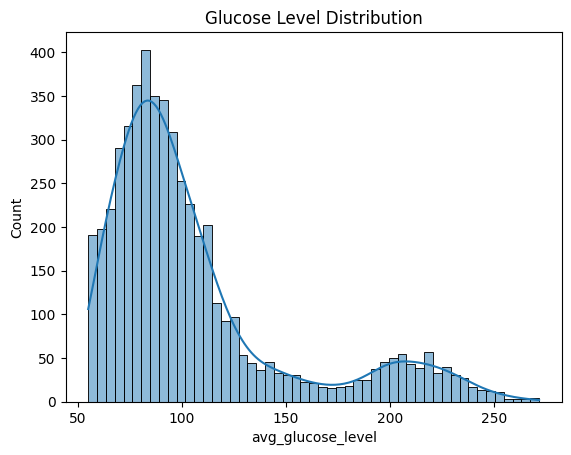

In [ ]:
sns.histplot(df['avg_glucose_level'], kde=True)
plt.title("Glucose Level Distribution")
plt.show()

# Data Preprocessing

checking missing value

In [ ]:
df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201
smoking_status,0


Fill missing values in 'bmi' with the mean

In [ ]:
df['bmi'].fillna(df['bmi'].mean(), inplace=True)

In [ ]:
df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,0
smoking_status,0


Encode categorical features using Label Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = ['gender', 'ever_married', 'work_type',
                    'Residence_type', 'smoking_status']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print("Info data setelah encoding:")
df.head()

Info data setelah encoding:


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,67.0,0,1,1,2,1,228.69,36.600000,1,1
1,0,61.0,0,0,1,3,0,202.21,28.893237,2,1
2,1,80.0,0,1,1,2,0,105.92,32.500000,2,1
3,0,49.0,0,0,1,2,1,171.23,34.400000,3,1
4,0,79.0,1,0,1,3,0,174.12,24.000000,2,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   int64  
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   int64  
 5   work_type          5110 non-null   int64  
 6   Residence_type     5110 non-null   int64  
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                5110 non-null   float64
 9   smoking_status     5110 non-null   int64  
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(8)
memory usage: 439.3 KB


In [ ]:
df['stroke'].value_counts()

,count
stroke,
0,4861
1,249


# Standarisasi
Scale numerical features using StandardScaler

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[['age', 'avg_glucose_level', 'bmi']] = scaler.fit_transform(df[
    ['age', 'avg_glucose_level', 'bmi']])

In [ ]:
X = df.drop('stroke', axis=1)
y = df['stroke']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Import and Training Model Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

Evaluate with Accuracy Score, Classification Report, Confusion Matrix

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Confusion Matrix (Logistic Regression):\n", confusion_matrix(y_test, y_pred))
print("\n Classification Report:\n", classification_report(y_test, y_pred))
print(" Accuracy Score:", accuracy_score(y_test, y_pred))

Confusion Matrix (Logistic Regression):
 [[719 241]
 [ 15  47]]

 Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.75      0.85       960
           1       0.16      0.76      0.27        62

    accuracy                           0.75      1022
   macro avg       0.57      0.75      0.56      1022
weighted avg       0.93      0.75      0.81      1022

 Accuracy Score: 0.7495107632093934


# Import dan Training Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

# Terapkan SMOTE untuk menyeimbangkan kelas
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# Latih model Random Forest dengan data yang sudah di-balance
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_balanced, y_train_balanced)

# Prediksi
rf_pred = rf_model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_balanced, y_train_balanced)

rf_pred = rf_model.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

print("Accuracy Score:", accuracy_score(y_test, rf_pred))

Confusion Matrix:
[[884  76]
 [ 47  15]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.92      0.93       960
           1       0.16      0.24      0.20        62

    accuracy                           0.88      1022
   macro avg       0.56      0.58      0.57      1022
weighted avg       0.90      0.88      0.89      1022

Accuracy Score: 0.8796477495107632


Evaluasi Random Forest

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Positive (TP): {tp}")
print(f"False Positive (FP): {fp}")
print(f"False Negative (FN): {fn}")
print(f"True Negative (TN): {tn}");

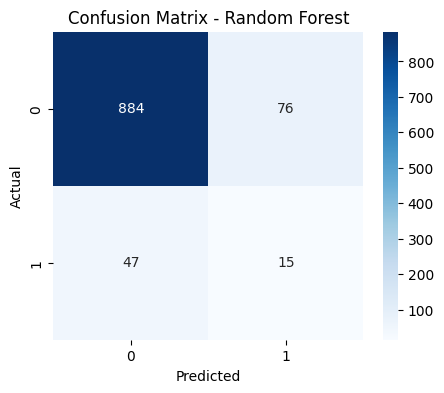

True Positive (TP): 15
False Positive (FP): 76
False Negative (FN): 47
True Negative (TN): 884


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

tn, fp, fn, tp = cm_rf.ravel()
print(f"True Positive (TP): {tp}")
print(f"False Positive (FP): {fp}")
print(f"False Negative (FN): {fn}")
print(f"True Negative (TN): {tn}");

perbandingan

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Matrix evaluasi Logistic Regression
acc_log = accuracy_score(y_test, y_pred)
prec_log = precision_score(y_test, y_pred, zero_division=0)
rec_log = recall_score(y_test, y_pred, zero_division=0)
f1_log = f1_score(y_test, y_pred, zero_division=0)

# Mtarix evaluasi Random Forest
acc_rf = accuracy_score(y_test, rf_pred)
prec_rf = precision_score(y_test, rf_pred, zero_division=0)
rec_rf = recall_score(y_test, rf_pred, zero_division=0)
f1_rf = f1_score(y_test, rf_pred, zero_division=0)

# Susun ke dalam tabel
comparison_data = {
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [acc_log, acc_rf],
    'Precision': [prec_log, prec_rf],
    'Recall': [rec_log, rec_rf],
    'F1-Score': [f1_log, f1_rf]
}

comparison_df = pd.DataFrame(comparison_data)

comparison_df['Accuracy'] = comparison_df['Accuracy'].map('{:.2%}'.format)
comparison_df['Precision'] = comparison_df['Precision'].map('{:.2%}'.format)
comparison_df['Recall'] = comparison_df['Recall'].map('{:.2%}'.format)
comparison_df['F1-Score'] = comparison_df['F1-Score'].map('{:.2%}'.format)

print("Tabel Perbandingan Logistic Regression vs Random Forest:")
display(comparison_df)

Tabel Perbandingan Logistic Regression vs Random Forest:


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,74.95%,16.32%,75.81%,26.86%
1,Random Forest,87.96%,16.48%,24.19%,19.61%


Feature Importance

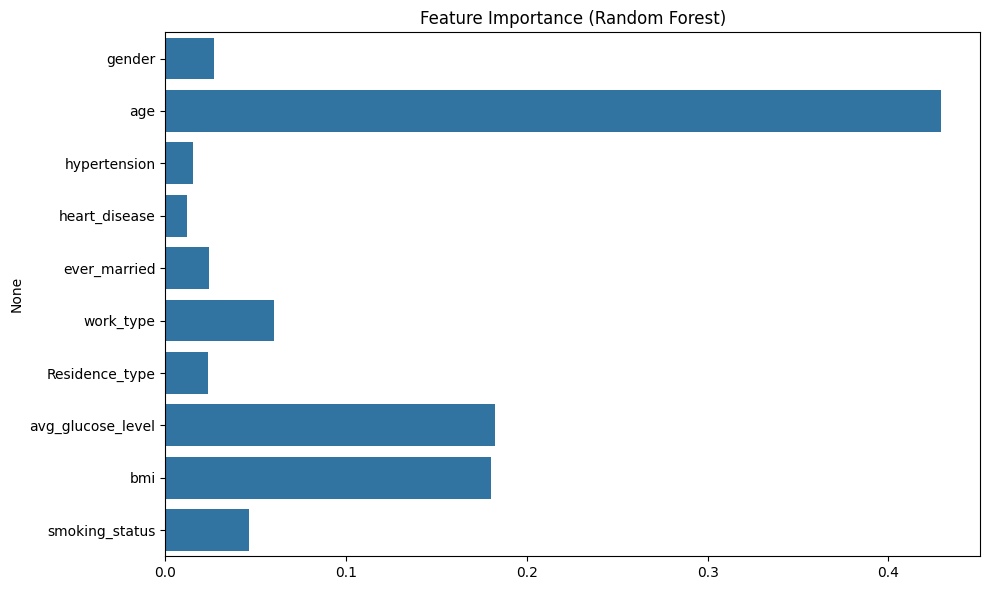

In [ ]:
import matplotlib.pyplot as plt

# Ambil importance
importances = rf_model.feature_importances_
features = X.columns

# Visualisasikan
plt.figure(figsize=(10,6))
sns.barplot(x=importances, y=features)
plt.title('Feature Importance (Random Forest)')
plt.tight_layout()
plt.show()